# Project lattice paths in order parameters space




In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "mean_field_theory/")
from utils_mean_field import *
from script_mean_field_covid import *
os.chdir('../lattice')



e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

# PATH CONSTANTS

In [3]:
PROTEIN_INIT = Proteins_utils.load_FASTA(
        "../lattice/msa/output_msa_structure_0_beta_1000.fasta"
    )[0]  # Load the protein sequence from the FASTA file.

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
print("sites upper face", sites)
w_bias = np.zeros((PROTEIN_INIT.shape[0], 20, 1))
for site in sites:
    wt_aa = PROTEIN_INIT[site]
    print("wt_aa", Proteins_utils.num2seq(np.array([wt_aa])))
    # put a 1 everywhere except for the wt_aa
    for i in range(20):
        if i != wt_aa:
            w_bias[site, i, 0] = 1 
            

sites upper face [ 8  9 10 11 12 15 16 24 25]
wt_aa D
wt_aa E
wt_aa Y
wt_aa Q
wt_aa G
wt_aa P
wt_aa K
wt_aa K
wt_aa K


In [4]:
RBM = RBM_utils.loadRBM("rbm/RBM_structure_0_beta_1000")

wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
#concat bias
wgamma = np.concatenate((wgamma, w_bias), axis=2)

wgamma.shape#L, Q, M
#reshape to (M, L*Q)
wgamma_flat= wgamma.reshape(wgamma.shape[0]*wgamma.shape[1], wgamma.shape[2]).T

wgamma_flat.shape

(21, 540)

# Gisaid sequences

# Get order parameters

In [5]:

#find the 2 hidden units with highest variance and decorrekated



In [6]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    

    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


# Get MCMC paths

In [7]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    #mean around axis 0
    print("proj_mat", proj_mat.shape)
    return proj_mat

#remove duplicates paths


In [8]:

seqs=Proteins_utils.load_FASTA('../lattice/msa/output_msa_structure_0_beta_1000.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])

one_hot_seqs.shape

(199, 540)

# Project




In [9]:
L=27
beta_w=1

folder='../mean_field_theory/results_scripts/lattice/mean_f_lattice_T_6_beta_w_'+str(beta_w)+'_beta_phi_1'
mopt = np.load(f"{folder}/mopt.npy")*L 
mopt.shape#(T, M) path of T steps and M hidden units
var = np.var(mopt[:,:-1], axis=0)
idx = np.argsort(var)[-1:]#indices of the 1 hidden units with
#project mopt on these 2 hidden units
import numpy as np
#idx and last one
idx=np.array([mopt.shape[1]-1,idx[0]])
mopt_2d = mopt[:, idx]
print("idx", idx)

dir_mcmc = f"../lattice/paths/w_upper_T6_beta_w_{beta_w}"
paths_mcmc=get_mcmc_proba_aa(dir_mcmc, wgamma_flat)

idx [20 12]
proj_mat (100, 7, 21)


paths_mcmc_2d 5 (7, 2)


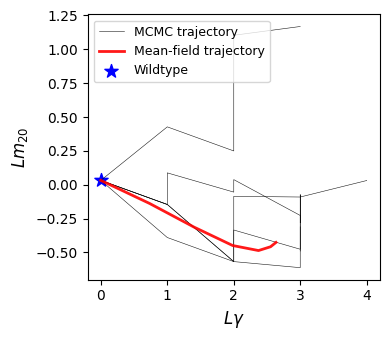

In [10]:
def project_and_plot_2d(one_hot_seqs, wgamma_flat):




    # --- Project reference points and trajectories ---


   

    import random
    random.seed(21)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 5)
    paths_mcmc_2d = [paths_mcmc[i][:, idx] for i in random_idxs]
    print("paths_mcmc_2d", len(paths_mcmc_2d), paths_mcmc_2d[0].shape)

    wt_2d = paths_mcmc_2d[0]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(4, 3.5))

    # Scatter of observed sequences


    # --- MCMC trajectories in thick black lines (only one label) ---
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)
        
    #plot mopt2D
    ax.plot(mopt_2d[:,0], mopt_2d[:,1],
            color='red', linewidth=2, alpha=0.9,
            label="Mean-field trajectory")

    # --- VOC stars and annotations ---


    # --- Wildtype star ---
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')

    # --- Labels and colorbar ---
    ax.set_ylabel(r"$Lm_{" + str(idx[0]) + "}$", fontsize=12)
    ax.set_xlabel(r"$L\gamma$", fontsize=12)



    ax.legend(loc='best', frameon=True, fontsize=9)

    # --- PRL-style black frame ---
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d(one_hot_seqs, wgamma_flat)


In [25]:
path_proba = '../mean_field_theory/results_scripts/lattice/mean_f_lattice_T_6_beta_w_1_beta_phi_1.npy'
probas = np.load(path_proba)  # shape: (amino_acid, step, site)
#round to cloestes 10^4
probas = np.round(probas, 6)  # Round to 4 decimal places

In [41]:
import numpy as np


# (1) Ensure each (step, site) column is a valid distribution
probas = probas / probas.sum(axis=0, keepdims=True)



C:\Users\maria\AppData\Local\Temp\ipykernel_14844\1348816189.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


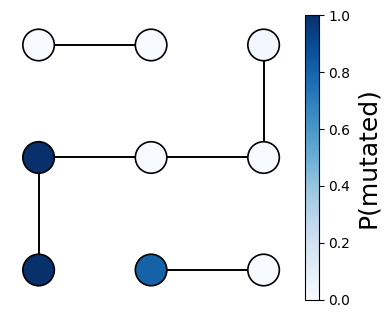

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

# ───────────────────────────  ALPHABET  ─────────────────────────── #
CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
aa_to_idx = {a:i for i,a in enumerate(CODE_RBM)}

# ───────────────────────────  LATTICE GEOMETRY  ─────────────────── #
LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),          # top row
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          # left column
    (9, 10),           # vertical 9 ↔ 10
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx = np.array(EPITOPE_SITES) - 1  # convert 1-based to 0-based

# ─────────────────  MUTATION PROBABILITY PER (step, site)  ──────────────── #
def mutation_probabilities(
    probas: np.ndarray,                # shape (A, T, S)
    wt_letters: dict[int, str] | None = None  # optional: {site(1-based): 'A', ...}
) -> np.ndarray:
    """
    Returns P(mutated) with shape (T, S):
    mutated means amino acid != reference aa at the first step.
    Reference aa per site:
      - if wt_letters provided, use it
      - else: argmax over amino acids at step 0
    """
    # normalize over amino acids
    denom = probas.sum(axis=0, keepdims=True)    # (1, T, S)
    denom = np.where(denom == 0.0, 1.0, denom)
    p = probas / denom                           # (A, T, S)

    A, T, S = p.shape

    # Build reference index per site (length S)
    ref_idx = np.empty(S, dtype=int)

    if wt_letters is not None:
        # wt_letters keyed by 1-based site index
        for s0 in range(S):
            site_1b = s0 + 1
            if site_1b in wt_letters:
                ref_idx[s0] = aa_to_idx[wt_letters[site_1b]]
            else:
                # fallback to most probable at step 0 if missing
                ref_idx[s0] = int(np.argmax(p[:, 0, s0]))
    else:
        ref_idx = np.argmax(p[:, 0, :], axis=0)  # (S,)

    # P(mutated) = 1 - P(reference aa)
    # gather p_ref[t, s] = p[ref_idx[s], t, s]
    row = ref_idx[np.newaxis, :]                 # (1, S)
    col = np.arange(S)[np.newaxis, :]            # (1, S)
    # for each t, pick p[row, t, col]
    p_ref = p[row, np.arange(T)[:, None], col]   # (T, S)
    p_mut = 1.0 - p_ref
    return p_mut

# ─────────────────────────────  DRAWING  ─────────────────────────── #
def draw_epitope_scalar(
    ax,
    centre=(0.0, 0.0),
    value_map=None,          # dict {site:int -> float} for 9 sites
    edge_colour="black",
    scale=0.35,
    radius=0.14,
    z=3,
    cmap_name="Blues",
    norm=None
):
    """
    Draw 3×3 epitope: bonds + circles colored by provided scalar (no letters).
    """
    cx, cy = centre
    cmap = get_cmap(cmap_name)
    if norm is None:
        vmax = max(value_map.values()) if value_map else 1.0
        norm = Normalize(vmin=0.0, vmax=vmax)

    # bonds
    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot(
            [cx + scale*xa, cx + scale*xb],
            [cy + scale*ya, cy + scale*yb],
            lw=1.4, color=edge_colour, zorder=z
        )

    # circles
    for site, (dx, dy) in LATTICE.items():
        v = value_map.get(site, 0.0)
        face = cmap(norm(v))
        circ = Circle(
            (cx + scale*dx, cy + scale*dy),
            radius*scale,
            facecolor=face,
            edgecolor=edge_colour,
            lw=1.2,
            zorder=z+1
        )
        ax.add_patch(circ)

    return norm, cmap

# ─────────────────────────  HIGH-LEVEL PLOTTER  ──────────────────────── #
def plot_epitope_pmut(
    probas: np.ndarray,            # (A, T, S)
    step: int,
    wt_letters: dict[int, str] | None = None,  # optional reference
    cmap_name: str = "Blues"
    #
):
    """
    Plot epitope colored by P(mutated) at a given step.
    If wt_letters is None, reference aa at each site is argmax at step 0.
    """
    p_mut = mutation_probabilities(probas, wt_letters=wt_letters)  # (T, S)

    # restrict to epitope sites
    vals = p_mut[step, sites_idx]                 # shape (9,)
    value_map = {site: v for site, v in zip(EPITOPE_SITES, vals)}

    # figure
    fig, ax = plt.subplots(figsize=(4, 4))
    norm = Normalize(vmin=0.0, vmax=1.0)         # probability in [0, 1]
    norm, cmap = draw_epitope_scalar(
        ax,
        centre=(0.0, 0.0),
        value_map=value_map,
        edge_colour="black",
        scale=0.35,
        radius=0.14,
        z=3,
        cmap_name=cmap_name,
        norm=norm
    )

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(mutated)", fontsize=18)

    ax.set_aspect("equal")
    ax.axis("off")
    # ax.set_title("Mean field")

    plt.tight_layout()
    return fig, ax

# ─────────────────────────────  USAGE  ───────────────────────────── #
# probas = np.load(path_proba)  # shape: (A, T, S)
# Option 1: from most probable aa at step 0
fig, ax = plot_epitope_pmut(probas, step=-1)

# Option 2: provide explicit wild-type letters for sites (1-based indexing)
# wt = {25:"Y", 26:"L", 9:"F", 12:"S", 11:"T", 10:"Q", 13:"N", 16:"V", 17:"I"}
# fig, ax = plot_epitope_pmut(probas, step=5, wt_letters=wt)
# plt.show()
